# ⭐ Phân tích Uy tín & Reviews
> Đào sâu vào nội dung reviews để hiểu điểm mạnh/yếu từng tiệm

**Mục tiêu**: Xác định tiệm vàng đáng tin, phân tích sentiment, tìm pattern trong feedback khách hàng.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True

shops = pd.read_csv('../data/shops.csv')
reviews = pd.read_csv('../data/reviews.csv')

# Merge
reviews_merged = reviews.merge(shops[['id', 'name', 'district', 'rating']], 
                                left_on='shop_id', right_on='id', suffixes=('_review', '_shop'))
print(f'Reviews: {len(reviews)}')
print(f'Reviews co text: {reviews["text"].notna().sum()}')
reviews_merged.head(2)

Reviews: 527
Reviews co text: 527


,id_review,shop_id,author,text,rating_review,date,source,created_at,id_shop,name,district,rating_shop
0,1,2,Nguyễn Thị Lan,"Dịch vụ rất tốt, nhân viên nhiệt tình. Giá cả ...",5.0,3 tuần trước,google,2026-03-14 05:14:14,2,PNJ Đà Nẵng - Hùng Vương,Hải Châu,4.9
1,2,2,Trần Văn Nam,"Cửa hàng rộng rãi, có nhiều mẫu đẹp. Nhân viên...",5.0,1 tháng trước,google,2026-03-14 05:14:14,2,PNJ Đà Nẵng - Hùng Vương,Hải Châu,4.9


## 1. Sentiment — Từ khóa tích cực vs tiêu cực

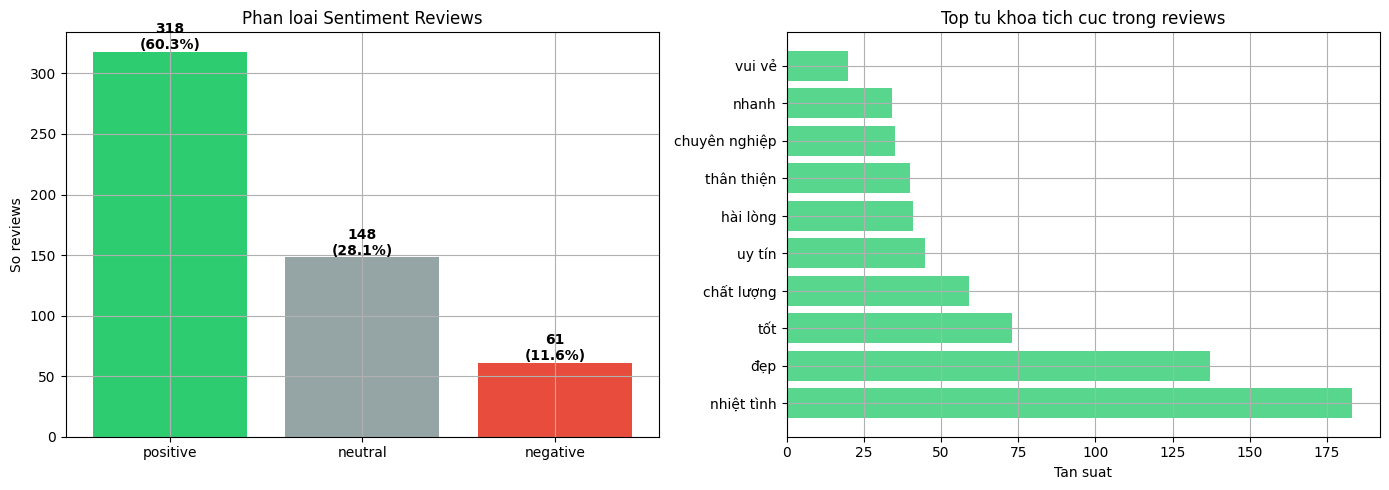

sentiment
positive    318
neutral     148
negative     61
Name: count, dtype: int64


In [2]:
POSITIVE_WORDS = [
    'tốt', 'tuyệt', 'đẹp', 'uy tín', 'hài lòng', 'chuyên nghiệp', 'nhiệt tình',
    'thân thiện', 'nhanh', 'chính hãng', 'đảm bảo', 'tin tưởng', 'chất lượng',
    'rẻ', 'hợp lý', 'giá tốt', 'phục vụ tốt', 'vui vẻ', 'sạch', 'tư vấn tốt',
    'recommend', 'good', 'great', 'excellent'
]

NEGATIVE_WORDS = [
    'tệ', 'kém', 'chậm', 'đắt', 'thái độ', 'bất lịch sự', 'lừa đảo', 'giả',
    'không tốt', 'thất vọng', 'không hài lòng', 'khó chịu', 'lâu', 'nhầm',
    'xấu', 'tránh', 'không nên', 'cẩn thận', 'bad', 'terrible', 'poor'
]

def count_keywords(text, keywords):
    if not isinstance(text, str):
        return 0
    text_lower = text.lower()
    return sum(1 for kw in keywords if kw in text_lower)

reviews['pos_score'] = reviews['text'].apply(lambda x: count_keywords(x, POSITIVE_WORDS))
reviews['neg_score'] = reviews['text'].apply(lambda x: count_keywords(x, NEGATIVE_WORDS))
reviews['sentiment'] = reviews.apply(lambda r: 'positive' if r['pos_score'] > r['neg_score']
                                      else ('negative' if r['neg_score'] > r['pos_score'] else 'neutral'), axis=1)

sentiment_counts = reviews['sentiment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_sent = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#95a5a6'}
axes[0].bar(sentiment_counts.index, sentiment_counts.values,
            color=[colors_sent[s] for s in sentiment_counts.index])
axes[0].set_title('Phan loai Sentiment Reviews')
axes[0].set_ylabel('So reviews')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 2, f'{v}\n({v/len(reviews)*100:.1f}%)', ha='center', fontweight='bold')

# Top positive keywords
all_text = ' '.join(reviews['text'].dropna().str.lower())
pos_freq = Counter(kw for kw in POSITIVE_WORDS if kw in all_text for _ in range(all_text.count(kw)))
top_pos = dict(sorted(pos_freq.items(), key=lambda x: x[1], reverse=True)[:10])
axes[1].barh(list(top_pos.keys()), list(top_pos.values()), color='#2ecc71', alpha=0.8)
axes[1].set_title('Top tu khoa tich cuc trong reviews')
axes[1].set_xlabel('Tan suat')

plt.tight_layout()
plt.savefig('../data/sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(sentiment_counts)

## 2. Top tiệm nhiều reviews nhất — Mức độ phổ biến

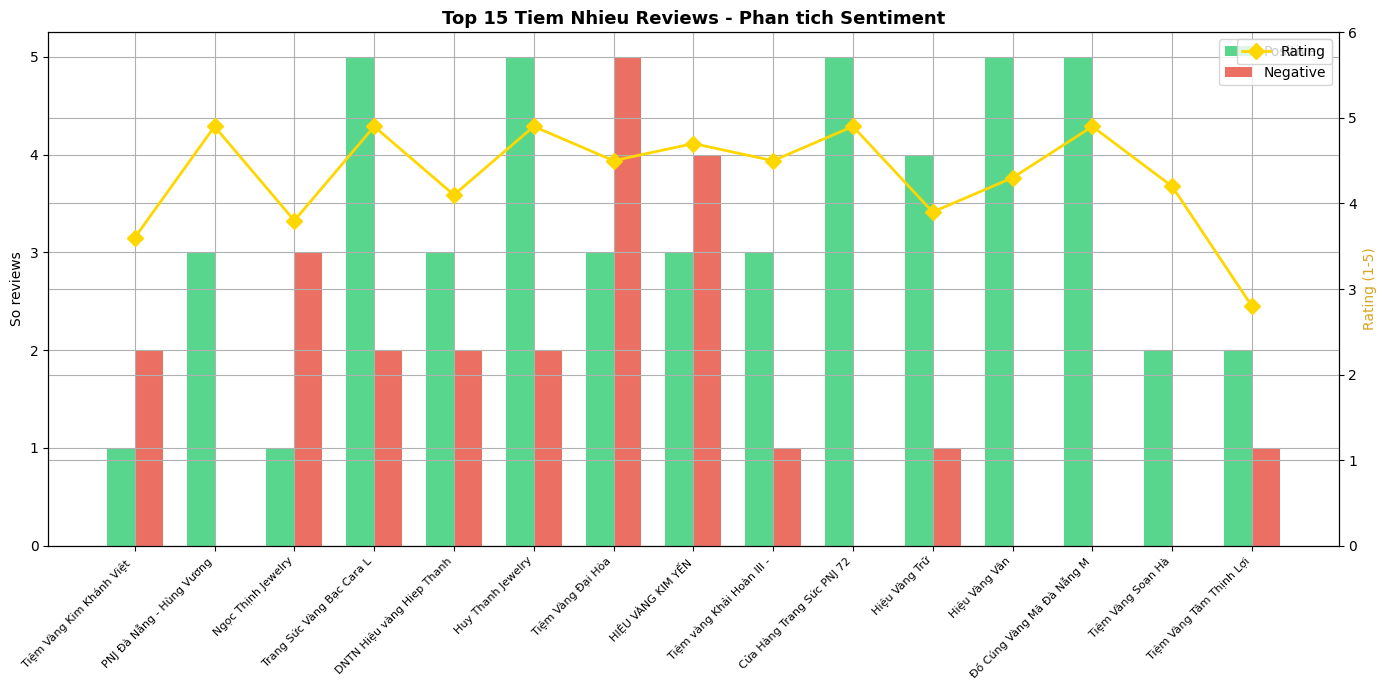

In [3]:
reviews_per_shop = reviews.groupby('shop_id').agg(
    total_reviews=('id', 'count'),
    avg_rating=('rating', 'mean'),
    positive_count=('pos_score', lambda x: (x > 0).sum()),
    negative_count=('neg_score', lambda x: (x > 0).sum())
).reset_index()

shop_reputation = reviews_per_shop.merge(shops[['id', 'name', 'district', 'rating']],
                                          left_on='shop_id', right_on='id')
shop_reputation['pos_rate'] = shop_reputation['positive_count'] / shop_reputation['total_reviews'] * 100

top15_popular = shop_reputation.nlargest(15, 'total_reviews')

fig, ax = plt.subplots(figsize=(14, 7))
x = range(len(top15_popular))
w = 0.35
b1 = ax.bar([i - w/2 for i in x], top15_popular['positive_count'], w, label='Positive', color='#2ecc71', alpha=0.8)
b2 = ax.bar([i + w/2 for i in x], top15_popular['negative_count'], w, label='Negative', color='#e74c3c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([n[:25] for n in top15_popular['name']], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('So reviews')
ax.set_title('Top 15 Tiem Nhieu Reviews - Phan tich Sentiment', fontsize=13, fontweight='bold')
ax.legend()
# Rating overlay
ax2 = ax.twinx()
ax2.plot(x, top15_popular['rating'], 'D-', color='gold', linewidth=2, markersize=8, label='Rating')
ax2.set_ylabel('Rating (1-5)', color='goldenrod')
ax2.set_ylim(0, 6)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../data/top_shops_reviews.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Xếp hạng uy tín tổng hợp

In [4]:
shops_rated = shops[shops['rating'] > 0].copy()
shops_rated['review_count_filled'] = shops_rated['review_count'].fillna(0)

# Composite trust score
max_reviews = shops_rated['review_count_filled'].max()
shops_rated['normalized_reviews'] = shops_rated['review_count_filled'] / max_reviews
shops_rated['trust_score'] = (0.7 * shops_rated['rating'] / 5 +
                               0.3 * shops_rated['normalized_reviews']) * 100

# Classify chains vs independent
chains = ['PNJ', 'DOJI', 'SJC', 'BTMC']
shops_rated['type'] = shops_rated['name'].apply(
    lambda n: next((c for c in chains if c in n), 'Independent')
)

print('=== BANG XEP HANG UY TIN ===')
print(f'{"Hang":>4} {"Ten tiem":40} {"Quan":15} {"Rating":>8} {"Reviews":>8} {"Trust":>8} {"Loai":12}')
print('-' * 100)
for i, (_, row) in enumerate(shops_rated.nlargest(30, 'trust_score').iterrows(), 1):
    print(f'{i:>4} {row["name"][:40]:40} {str(row["district"])[:15]:15} '
          f'{row["rating"]:>8.1f} {int(row["review_count_filled"]):>8} '
          f'{row["trust_score"]:>8.1f} {row["type"]:12}')

print('\n=== SO SANH CHAIN vs INDEPENDENT ===')
chain_vs_ind = shops_rated.groupby('type')['rating'].agg(['mean', 'median', 'count'])
print(chain_vs_ind)

=== BANG XEP HANG UY TIN ===
Hang Ten tiem                                 Quan              Rating  Reviews    Trust Loai        
----------------------------------------------------------------------------------------------------
   1 Huy Thanh Jewelry                        Thanh Khê            4.9     1258     98.6 Independent 
   2 Trang Sức Uy Tín Đà Nẵng - Phước swiss   Hải Châu             5.0      853     90.3 Independent 
   3 Cửa Hàng Trang Sức PNJ Vincom Đà Nẵng    Sơn Trà              5.0      482     81.5 PNJ         
   4 Cửa Hàng Trang Sức PNJ 513 Điện Biên Phủ Thanh Khê            4.9      513     80.8 PNJ         
   5 Cửa hàng Trang sức PNJ tại Go! Đà Nẵng   Thanh Khê            5.0      407     79.7 PNJ         
   6 Cửa Hàng Trang Sức PNJ 455 Núi Thàn Hải Châu             4.9      455     79.5 PNJ         
   7 Cửa Hàng Trang Sức PNJ 359 Phan Châu Tri Hải Châu             5.0      359     78.6 PNJ         
   8 Cửa Hàng Trang Sức PNJ 411 Lê Duẩn Đà Nẵ Hải Châu

## 4. Phân tích nội dung reviews — Khách hàng nói gì?

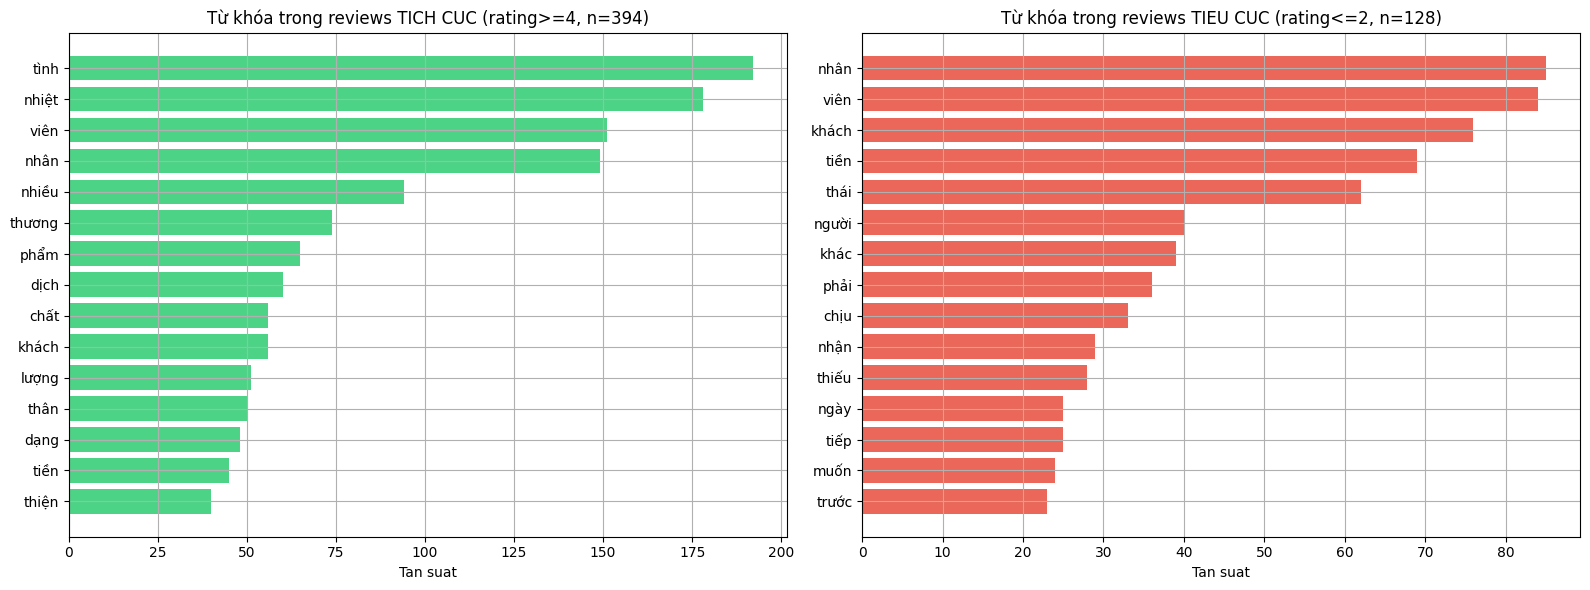

In [5]:
# Most common phrases in positive reviews (rating >= 4)
pos_reviews = reviews[reviews['rating'] >= 4]['text'].dropna()
neg_reviews = reviews[reviews['rating'] <= 2]['text'].dropna()

def extract_keywords(texts, min_len=4):
    all_words = []
    for text in texts:
        words = re.findall(r'[a-zA-Zàáâãèéêìíòóôõùúăđĩũơưạảấầẩẫậắằẳẵặẹẻẽếềểễệỉịọỏốồổỗộớờởỡợụủứừửữựỳỵỷỹ]+', 
                           text.lower())
        all_words.extend([w for w in words if len(w) >= min_len])
    return Counter(all_words)

pos_words = extract_keywords(pos_reviews)
neg_words = extract_keywords(neg_reviews)

# Remove common stop words
stop = {'shop', 'cửa', 'hàng', 'tiệm', 'vàng', 'mình', 'được', 'bạn', 'tôi', 'này',
        'không', 'nhưng', 'trong', 'cũng', 'rất', 'nơi', 'tại', 'cho', 'với', 'khi',
        'store', 'gold', 'shop', 'jewelry', 'đây', 'đến', 'một', 'have', 'good'}
for w in stop:
    pos_words.pop(w, None)
    neg_words.pop(w, None)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_pos = dict(pos_words.most_common(15))
axes[0].barh(list(top_pos.keys()), list(top_pos.values()), color='#2ecc71', alpha=0.85)
axes[0].set_title(f'Từ khóa trong reviews TICH CUC (rating>=4, n={len(pos_reviews)})')
axes[0].set_xlabel('Tan suat')
axes[0].invert_yaxis()

if len(neg_reviews) > 0:
    top_neg = dict(neg_words.most_common(15))
    axes[1].barh(list(top_neg.keys()), list(top_neg.values()), color='#e74c3c', alpha=0.85)
    axes[1].set_title(f'Từ khóa trong reviews TIEU CUC (rating<=2, n={len(neg_reviews)})')
    axes[1].set_xlabel('Tan suat')
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, 'Khong du reviews tieu cuc', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('../data/keyword_analysis.png', dpi=150, bbox_inches='tight')
plt.show()